In [18]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8572\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [10]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [11]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

# PDF And QQPlot Before Mathematical_Transformer

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8572\781458339.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


Text(0.5, 1.0, 'Age QQ Plot')

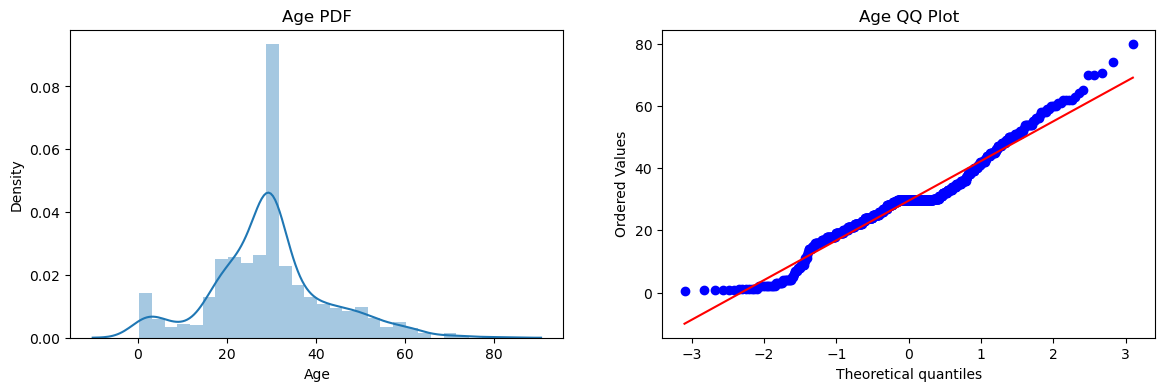

In [14]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

C:\Users\Saqib Ali\AppData\Local\Temp\ipykernel_8572\2965418191.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


Text(0.5, 1.0, 'Fare QQ Plot')

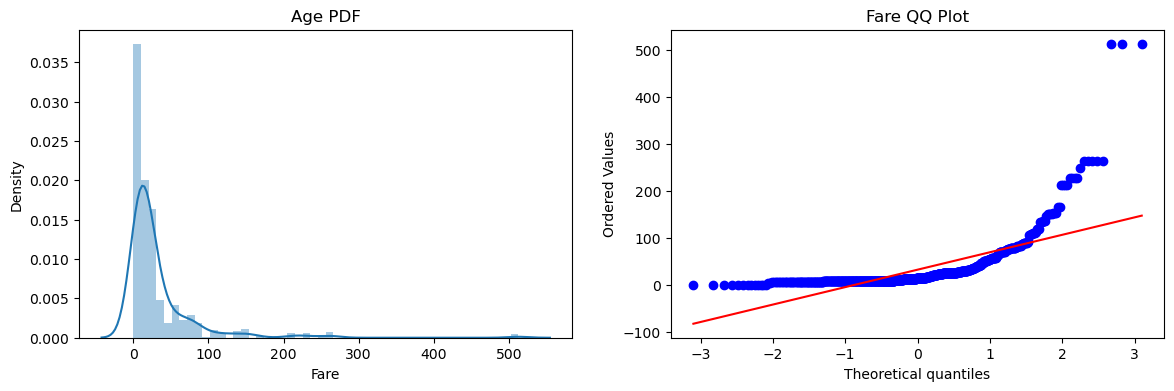

In [16]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

# Model Training before Mathematical_Transformer [Age, Fare]

In [19]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [22]:
clf.fit(x_train, y_train)
clf2.fit(x_train, y_train)

y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

print("LR Accuracy", accuracy_score(y_test,y_pred))
print("DT Accuracy", accuracy_score(y_test,y_pred2))

LR Accuracy 0.6480446927374302
DT Accuracy 0.6703910614525139


# Mathematical_transformer[Age, Fare]

In [29]:
trf = FunctionTransformer(func=np.log1p)

x_train_transformed = trf.fit_transform(x_train)
x_test_transformed = trf.fit_transform(x_test)

# Model Training After Mathematical_transformer[Age, Fare]

In [35]:
y_train.shape

(712,)

In [38]:
clf.fit(x_train_transformed, y_train)
clf2.fit(x_train_transformed, y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print("LR Accuracy", accuracy_score(y_test,y_pred))
print("DT Accuracy", accuracy_score(y_test,y_pred2))

LR Accuracy 0.6815642458100558
DT Accuracy 0.6983240223463687


# Cross_Val_Score

In [43]:
x_transformed = trf.fit_transform(x)

print("Accuracy Lr",np.mean(cross_val_score(clf, x_transformed, y, scoring="accuracy", cv=10)))
print("Accuracy Dt",np.mean(cross_val_score(clf2, x_transformed, y, scoring="accuracy", cv=10)))

Accuracy Lr 0.678027465667915
Accuracy Dt 0.6610986267166042


# QQPLot Before & After Mathematical_Transformer

Text(0.5, 1.0, 'Age After transformer')

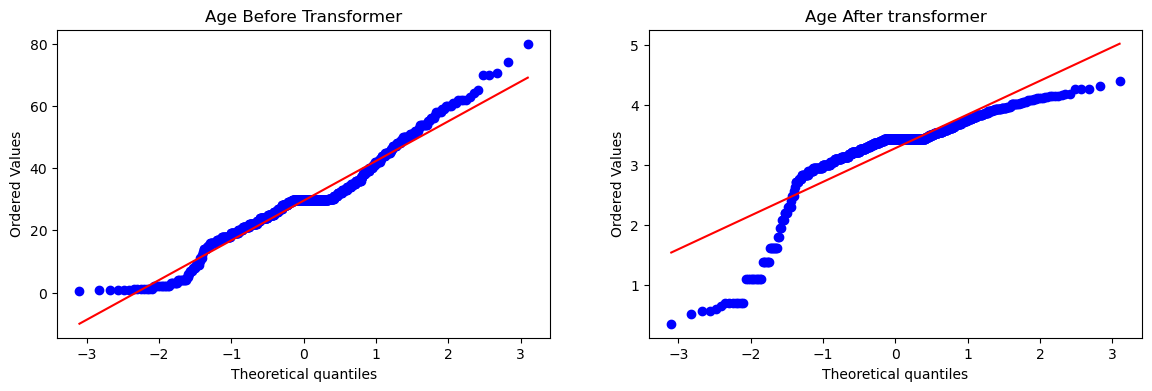

In [46]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Age'], dist="norm",plot=plt)
plt.title('Age Before Transformer')

plt.subplot(122)
stats.probplot(x_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After transformer')

Text(0.5, 1.0, 'Fare After transformer')

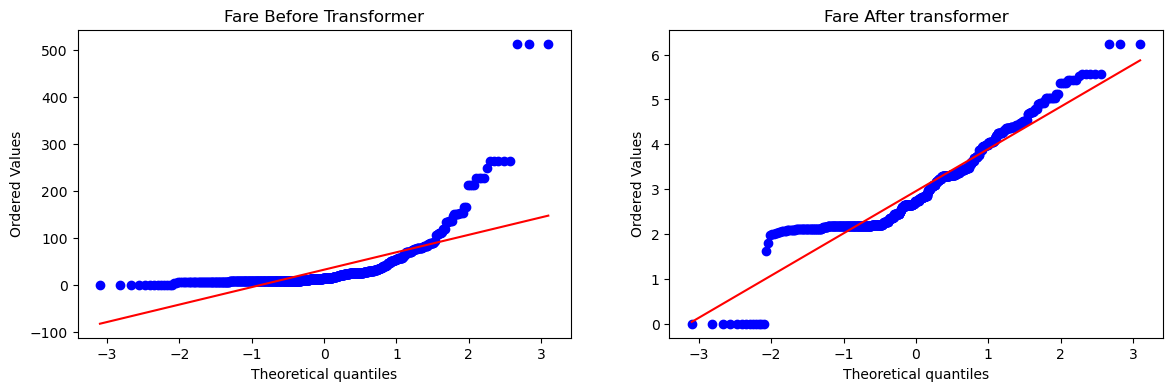

In [47]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'], dist="norm",plot=plt)
plt.title('Fare Before Transformer')

plt.subplot(122)
stats.probplot(x_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After transformer')

# Mathematical_Transformer[Fare]

In [51]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

x_train_transformed = trf2.fit_transform(x_train)
x_test_transformed = trf2.fit_transform(x_test)

# model Training After Mathematical_transfomer[Fare]

In [52]:
clf.fit(x_train_transformed, y_train)
clf2.fit(x_train_transformed, y_train)

y_pred = clf.predict(x_test_transformed)
y_pred2 = clf2.predict(x_test_transformed)

print("LR Accuracy", accuracy_score(y_test,y_pred))
print("DT Accuracy", accuracy_score(y_test,y_pred2))

LR Accuracy 0.6703910614525139
DT Accuracy 0.6815642458100558


# cross_val_score

In [53]:
x_transformed = trf2.fit_transform(x)

print("Accuracy Lr",np.mean(cross_val_score(clf, x_transformed, y, scoring="accuracy", cv=10)))
print("Accuracy Dt",np.mean(cross_val_score(clf2, x_transformed, y, scoring="accuracy", cv=10)))

Accuracy Lr 0.6712609238451936
Accuracy Dt 0.6610486891385767


# Check More Function_Transformer

In [85]:
def apply_transform(transform):
    x = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

    x_train = trf2.fit_transform(x)

    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,x_train,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(x['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(x_train[:,0], dist="norm", plot=plt)
    plt.title('Fare After')

# Reciporcal_transformer

Accuracy 0.6712609238451936


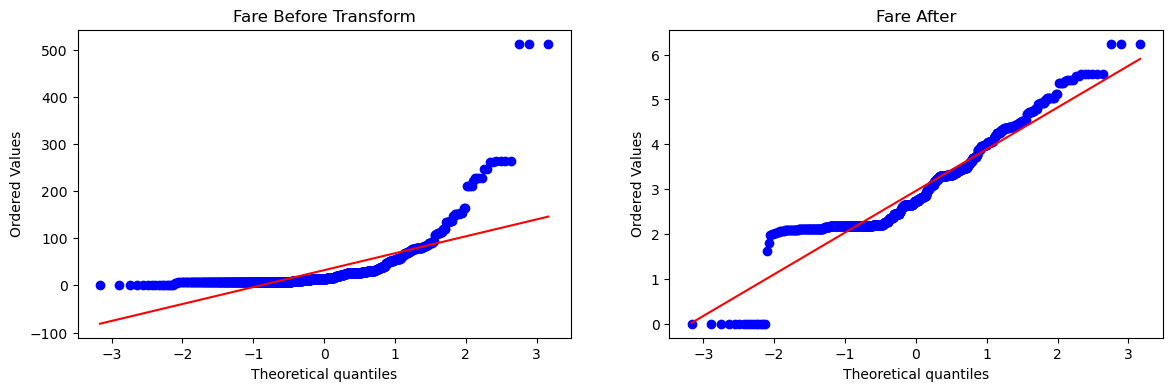

In [86]:
test = 1/(x+0.0000001)
apply_transform(test)

# Square Transformer

Accuracy 0.6712609238451936


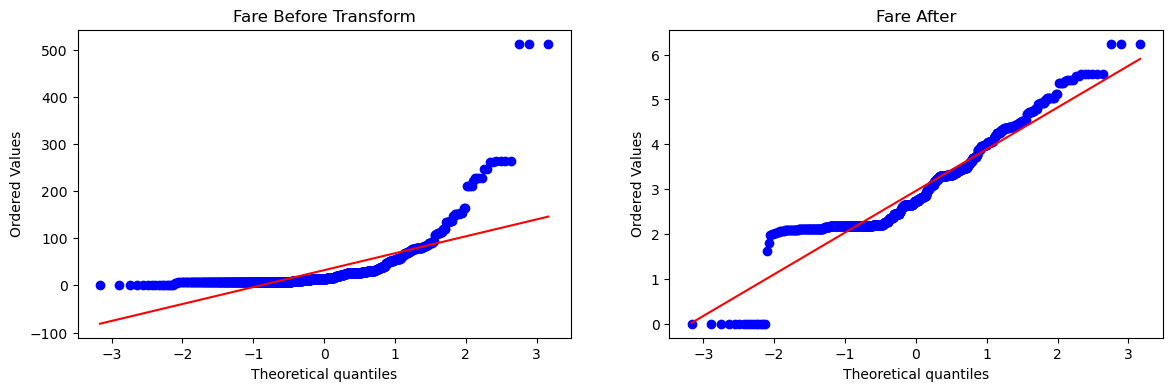

In [87]:
test = x**2
apply_transform(test)

# sqrt_transformer

Accuracy 0.6712609238451936


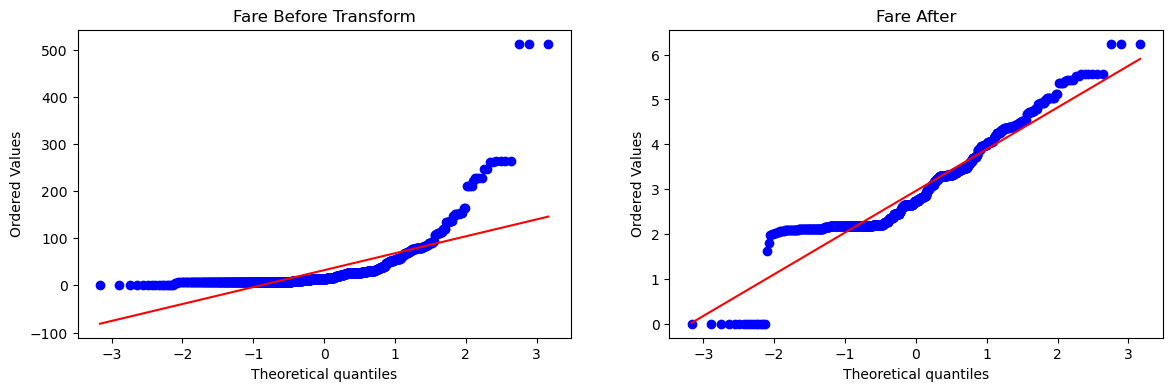

In [84]:
test = x**1/2
apply_transform(test)